# Predicting Titanic Survival with a Feed-Forward Neural Network

**Objective:** train a small Keras neural network that predicts whether a passenger survived the Titanic disaster, using attributes like ticket class, sex, age and fare.


### Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. About the Data

**Source:** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

| Column | Meaning |
|---|---|
| PassengerId | Row identifier |
| Pclass | Ticket class (1 = First, 2 = Second, 3 = Third) |
| Name | Passenger name |
| Sex | male / female |
| Age | Age in years |
| SibSp | # siblings/spouses aboard |
| Parch | # parents/children aboard |
| Ticket | Ticket number |
| Fare | Fare paid |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C, Q, S) |
| Survived | Target: 0 = died, 1 = survived |


Reading the raw file into a DataFrame and taking a first look at its shape and contents:

In [33]:
source = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(source)

print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Data Preprocessing

#### 4.1 Handling Missing Values

Checking column dtypes and where values are missing before doing any cleanup:

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Counting missing values per column and looking at the overall survival rate, so any imbalance is visible up front:

In [35]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nSurvival rate:")
print(df['Survived'].value_counts(normalize=True))


Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Substituting missing or null age values with the median:

In [36]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Substituting missing or null embarked values with the mode value

In [37]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Since more than half of the Cabin values are null, dropping the Cabin column

In [38]:
df = df.drop(columns=['Cabin'])
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [39]:
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Dropping the 'PassengerId', 'Name' and 'Ticket' columns since it won't help in the prediction.

In [40]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])


#### 4.2 Encoding

In [41]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [42]:
# Initialize OneHotEncoder with drop='first' to avoid multicollinearity
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Fit and transform the 'Embarked' column
embarked_encoded = ohe.fit_transform(df[['Embarked']])

# Create a DataFrame with the one-hot encoded columns
# Use get_feature_names_out to get the column names dynamically
embarked_df = pd.DataFrame(embarked_encoded, columns=ohe.get_feature_names_out(['Embarked']), index=df.index)

# Concatenate the new columns with the original DataFrame and drop the original 'Embarked' column
df = pd.concat([df.drop('Embarked', axis=1), embarked_df], axis=1)

# Display the head of the DataFrame to show the changes
display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0.0,1.0
1,1,1,1,38.0,1,0,71.2833,0.0,0.0
2,1,3,1,26.0,0,0,7.9250,0.0,1.0
3,1,1,1,35.0,1,0,53.1000,0.0,1.0
4,0,3,0,35.0,0,0,8.0500,0.0,1.0


#### 4.3 Splitting Data

Splitting to train-test

In [43]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (712, 8)
Test shape: (179, 8)


#### 4.4 Feature Scaling

In [44]:
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
binary_features = ['Sex', 'Embarked_Q', 'Embarked_S']

scaler = StandardScaler()

# Scale numerical features
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_features])
X_test_scaled_numerical = scaler.transform(X_test[numerical_features])

# Combine scaled numerical features with unscaled binary features
X_train_scaled = np.concatenate((X_train_scaled_numerical, X_train[binary_features].values), axis=1)
X_test_scaled = np.concatenate((X_test_scaled_numerical, X_test[binary_features].values), axis=1)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (712, 8)
X_test_scaled shape: (179, 8)


## 5. Building the Network




#### 5.1 Neural Network Architecture

**Architecture**
- Input layer sized to the number of features
- Two hidden `Dense` layers with ReLU activation (with dropout in between to fight overfitting)
- A single sigmoid output node for the binary label


In [45]:
n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

#### 5.2 Compile the Model

**Compilation**
- Loss: binary cross-entropy
- Optimizer: Adam
- Tracked metric: accuracy

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

#### 5.3 Train the Model

In [47]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6362 - loss: 0.6314 - val_accuracy: 0.6154 - val_loss: 0.6199
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6467 - loss: 0.6096 - val_accuracy: 0.6853 - val_loss: 0.5912
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6960 - loss: 0.5766 - val_accuracy: 0.7483 - val_loss: 0.5714
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7276 - loss: 0.5619 - val_accuracy: 0.7692 - val_loss: 0.5572
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7188 - loss: 0.5513 - val_accuracy: 0.7692 - val_loss: 0.5431
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7258 - loss: 0.5414 - val_accuracy: 0.7762 - val_loss: 0.5310
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7364 - loss: 0.5377 - val_accuracy: 0.7692 - val_loss: 0.5183
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7610 - loss: 0.5144 - val_accuracy: 0.7832 - v

## 6. Evaluate the Model

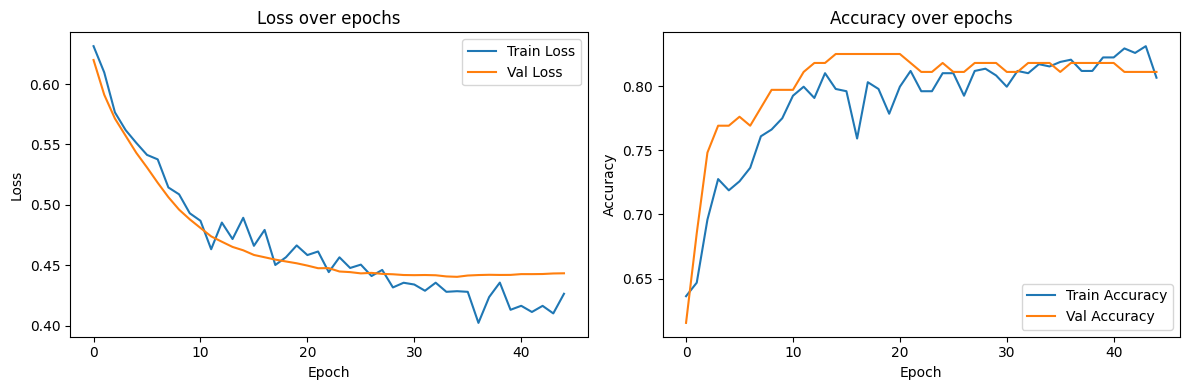

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


#### 6.1 Accuracy, Precision, Recall, and F1-Score

In [49]:
y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy:  0.8101
Precision: 0.8302
Recall:    0.6377
F1-score:  0.7213


##### Evaluation Metrics

- **Accuracy**: The proportion of correctly classified instances (both true positives and true negatives) out of the total instances.
- **Precision**: The proportion of true positive predictions among all positive predictions. It answers: "Of all instances predicted as positive, how many are actually positive?"
- **Recall**: The proportion of true positive predictions among all actual positive instances. It answers: "Of all actual positive instances, how many were correctly predicted?"
- **F1-score**: The harmonic mean of precision and recall. It's a useful metric when you need a balance between precision and recall, especially in cases of uneven class distribution.

#### 6.2 Confusion Matrix and ROC Curve

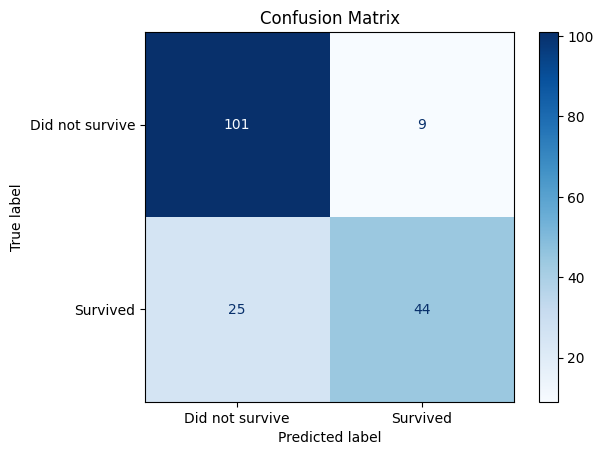

In [50]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


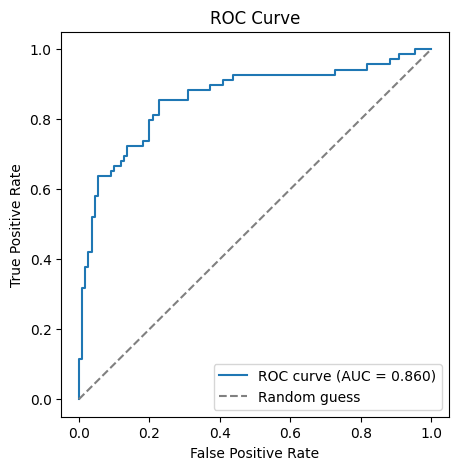

In [51]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 7. Conclusion

### 7.1 Key Findings and Model Performance

**Data Preprocessing:**
- Missing values in 'Age' were imputed with the median, and 'Embarked' with the mode.
- The 'Cabin' column was dropped due to a high percentage of missing values.
- Irrelevant columns like 'PassengerId', 'Name', and 'Ticket' were removed.
- Categorical features 'Sex' and 'Embarked' were encoded: 'Sex' was mapped to binary (0/1), and 'Embarked' was one-hot encoded using `OneHotEncoder` with `drop='first'`.
- Numerical features ('Pclass', 'Age', 'SibSp', 'Parch', 'Fare') were scaled using `StandardScaler`, while binary features ('Sex', 'Embarked_Q', 'Embarked_S') were intentionally left unscaled to preserve their interpretability.

**Model Architecture & Training:**
- A feed-forward neural network was built with an input layer, two hidden `Dense` layers (16 and 8 units, ReLU activation) with a `Dropout` layer (0.2) in between, and a single output `Dense` layer with sigmoid activation for binary classification.
- The model was compiled using the `Adam` optimizer, `binary_crossentropy` loss, and 'accuracy' as the metric.
- Training was performed for up to 100 epochs with a batch size of 16, using `EarlyStopping` based on validation loss to prevent overfitting.

**Model Performance on Test Set:**
- **Accuracy**: The model achieved an accuracy of **0.8101**, meaning it correctly predicted survival status for approximately 81.01% of the test set passengers.
- **Precision**: With a precision of **0.8302**, when the model predicted a passenger survived, it was correct about 83.02% of the time.
- **Recall**: A recall of **0.6377** indicates that the model correctly identified about 63.77% of all actual survivors.
- **F1-score**: The F1-score, which balances precision and recall, was **0.7213**.
- **ROC AUC**: The Area Under the Receiver Operating Characteristic Curve (AUC) was **0.860**, suggesting a good discriminatory power of the model.

**Summary:**
The model demonstrates a reasonable performance in predicting Titanic survival, with a good balance across accuracy, precision, and recall. The ROC curve further supports its ability to distinguish between survivors and non-survivors. The preprocessing steps, including careful handling of missing values and selective feature scaling, contributed to preparing the data effectively for the neural network.

### 7.2 Potential Improvements

While the current model shows reasonable performance, there are several avenues to explore for potential improvements:

1.  **Hyperparameter Tuning:**
    -   **Neural Network Architecture:** Experiment with different numbers of layers, neurons per layer, and activation functions (e.g., Leaky ReLU, ELU). The current architecture is relatively simple and might benefit from more complex configurations.
    -   **Dropout Rate:** Tune the dropout rate. A higher dropout rate might reduce overfitting, while a lower rate could allow the model to learn more complex patterns if it's currently underfitting.
    -   **Optimizer and Learning Rate:** Explore other optimizers like SGD with momentum, RMSprop, or Adam variants (e.g., Adamax, Nadam). Adjusting the learning rate for the chosen optimizer is crucial, possibly using learning rate schedules or adaptive learning rates.
    -   **Batch Size:** Experiment with different batch sizes. Larger batch sizes might speed up training but could lead to poorer generalization, while smaller batch sizes might lead to more stable gradients and better generalization but longer training times.
    -   **Regularization:** Beyond dropout, L1 or L2 regularization could be added to the dense layers to further combat overfitting.

2.  **Feature Selection and Engineering:**
    -   **Feature Engineering:** Create new features from existing ones. For example:
        -   **Family Size:** Combine 'SibSp' and 'Parch' into a 'FamilySize' feature. This could indicate whether a passenger was alone, with a small family, or a large family.
        -   **Title from Name:** Extract titles (Mr., Mrs., Miss, Master, etc.) from the 'Name' column. Titles can often be strong indicators of social status and gender, which might correlate with survival.
        -   **Fare per Person:** Divide 'Fare' by 'FamilySize' (or 1 if alone) to get a 'FarePerPerson' feature, as the fare might be for a group.
    -   **Feature Selection:** Even with the current features, techniques like Recursive Feature Elimination (RFE) or permutation importance could identify the most impactful features and potentially remove less important ones to simplify the model and reduce noise. More advanced methods like L1 regularization (Lasso) can also perform implicit feature selection.

3.  **Cross-Validation:**
    -   Implement k-fold cross-validation during training to get a more robust estimate of model performance and ensure the model generalizes well across different subsets of the data, rather than relying solely on a single train-validation split.

4.  **Ensemble Methods:**
    -   Consider combining multiple neural networks or integrating other machine learning models (e.g., Random Forest, Gradient Boosting) into an ensemble to improve predictive power.

### 7.3 Further Enhancements

Beyond the fundamental improvements in hyperparameter tuning and feature engineering, more advanced techniques can be employed:

1.  **More Complex Deep Learning Architectures:**
    *   **Deeper and Wider Networks:** Experiment with adding more hidden layers (making the network deeper) or increasing the number of neurons in existing layers (making it wider). Deeper networks can learn more abstract representations, but require careful handling to avoid vanishing/exploding gradients and overfitting.
    *   **Batch Normalization:** Incorporate Batch Normalization layers, especially in deeper networks. This technique normalizes the inputs of layers, stabilizing and speeding up the training process, and often improving generalization.
    *   **Residual Connections:** For very deep networks, residual connections (like those used in ResNet architectures) can help combat the vanishing gradient problem by allowing gradients to flow through skip connections, enabling the training of much deeper models.

2.  **Advanced Ensemble Models:**
    *   **Heterogeneous Ensembles:** Combine predictions from different types of models (e.g., the current Neural Network, a Random Forest, a Gradient Boosting Machine like XGBoost/LightGBM, and a Support Vector Machine). Each model might capture different patterns in the data, and combining their strengths can lead to a more robust and accurate final prediction.
    *   **Stacking/Meta-Learning:** Train several base models, and then train a meta-model (or 'learner') to make a final prediction based on the predictions of the base models. This sophisticated ensemble technique can often yield significant performance gains.
    *   **Bagging and Boosting Variants:** While basic ensemble concepts were mentioned, exploring advanced implementations like Adaptive Boosting (AdaBoost) or specific configurations of Gradient Boosting (e.g., with different objective functions or learning rates) can fine-tune performance. For Bagging, a more exhaustive search of Random Forest parameters could be beneficial.

By systematically exploring these advanced deep learning and ensemble techniques, there is significant potential to further improve the predictive accuracy and robustness of the Titanic survival model.